In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('customer.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

# CONVERTING COLUMNS NAME INTO LOWER CASE

In [4]:
df.columns=df.columns.str.lower().str.strip()

# CHANGE DATA TYPE 

In [5]:
df['totalcharges']=pd.to_numeric(df['totalcharges'], errors='coerce')

In [6]:
pd.to_numeric(df['totalcharges'], errors='coerce').isna().sum()

np.int64(11)

# DROP NULL VALUE

In [7]:
df=df.dropna()

In [8]:
df.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [9]:
df.describe()

,seniorcitizen,tenure,monthlycharges,totalcharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [10]:
df['customerid'].duplicated().sum()

np.int64(0)

# REPLACE VALUE : convert 0-->No  & 1-->Yes

In [11]:
df['seniorcitizen']=df['seniorcitizen'].replace({0:'No',1:'Yes'})

In [12]:
df['multiplelines']=df['multiplelines'].replace('No phone service','No')

In [13]:
df[df['seniorcitizen']=='Yes'].head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
20,8779-QRDMV,Male,Yes,No,No,1,No,No,DSL,No,...,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,39.65,39.65,Yes
30,3841-NFECX,Female,Yes,Yes,No,71,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,No,No,Two year,Yes,Credit card (automatic),96.35,6766.95,No
31,4929-XIHVW,Male,Yes,Yes,No,2,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),95.50,181.65,No
34,3413-BMNZE,Male,Yes,No,No,1,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,No,Bank transfer (automatic),45.25,45.25,No
50,8012-SOUDQ,Female,Yes,No,No,43,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,90.25,3838.75,No


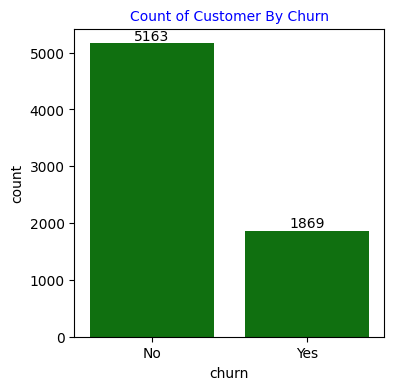

In [14]:
plt.figure(figsize=(4,4))
ax=sns.countplot(x=df['churn'],color='g')
ax.bar_label(ax.containers[0])
plt.title('Count of Customer By Churn',fontsize=10,color='b')
plt.show()

#The company has more retained customers than churned customers, indicating good customer retention.
Further analysis is needed to understand the factors contributing to customer churn

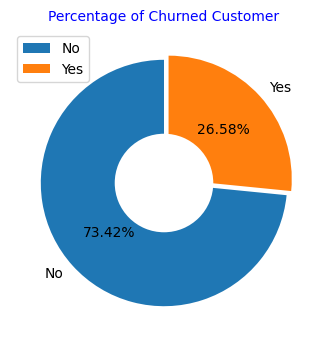

In [15]:
plt.figure(figsize=(4,4))
gp=df.groupby('churn').agg({'churn':'count'})
ex=[0.0,0.05]
plt.pie(gp['churn'],labels=gp.index,autopct="%1.2f%%",explode=ex,startangle=90)
plt.pie([1],colors='w',radius=0.4)
plt.title('Percentage of Churned Customer',fontsize=10,color='b')
plt.legend()
plt.show()

#Approximately 26% of customers have churned, while 74% remain with the company.

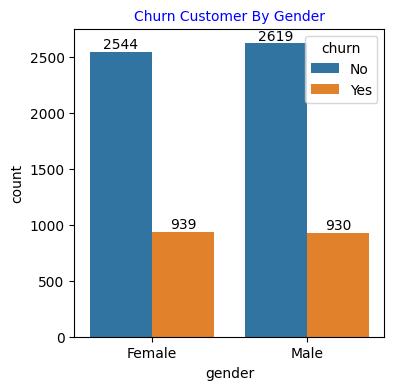

In [16]:
plt.figure(figsize=(4,4))
ax=sns.countplot(x='gender',data=df,hue='churn')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title('Churn Customer By Gender',fontsize=10,color='b')
plt.show()

#The churn distribution is almost the same for both male and female customers.
This suggests that gender has little to no significant impact on customer churn.

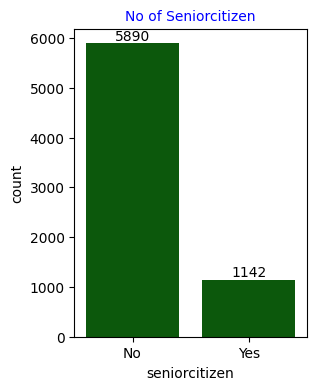

In [17]:
plt.figure(figsize=(3,4))
ax=sns.countplot(x='seniorcitizen',data=df,color='darkgreen')
ax.bar_label(ax.containers[0])
plt.title('No of Seniorcitizen',fontsize=10,color='b')
plt.show()

#Most customers are not senior citizens ,only (1142) customers are senior citizens. This indicates that the company's customer base is primarily composed of non-senior citizens.

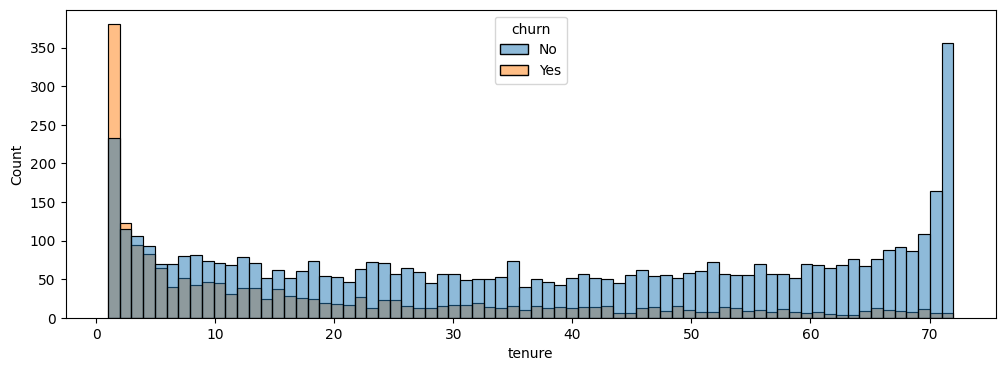

In [18]:
plt.figure(figsize=(12,4))
sns.histplot(x='tenure',data=df,bins=72,hue='churn')   
plt.show()

#Customers with shorter tenure (especially the first few months) have a higher churn rate. In contrast, customers with longer tenure are more likely to stay with the company, indicating that customer loyalty increases over time.

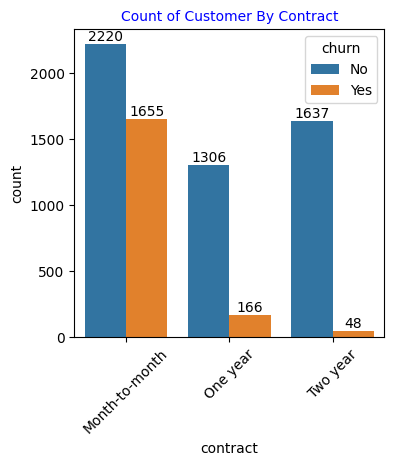

In [19]:
plt.figure(figsize=(4,4))
ax=sns.countplot(x='contract',data=df,hue='churn')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title('Count of Customer By Contract',fontsize=10,color='b')
plt.xticks(rotation=45)
plt.show()

#Customers with Month-to-Month contracts have the highest churn, while One-Year and Two-Year contract customers show much lower churn. This indicates that long-term contracts improve customer retention and reduce customer churn.

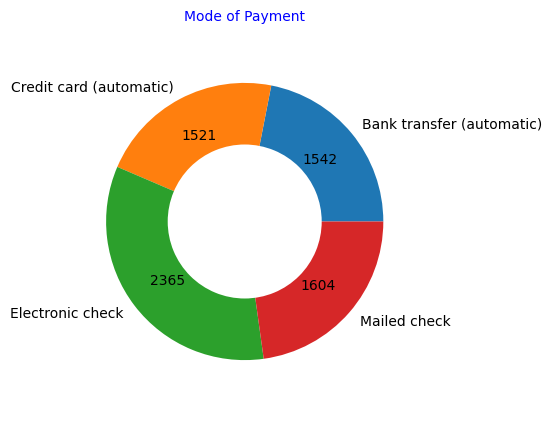

In [20]:
plt.figure(figsize=(5,5))
pmt=df.groupby('paymentmethod').agg({'paymentmethod':'count'})
plt.pie(pmt['paymentmethod'],labels=pmt.index,autopct=lambda p:f'{int(p * sum(pmt["paymentmethod"]) / 100)}',radius=0.9,pctdistance=0.7)
plt.pie([1],colors='w',radius=0.5)
plt.title("Mode of Payment",color='b',fontsize=10)
plt.show()

#Electronic Check is the most preferred payment method among customers. The other three payment methods are used less frequently and have nearly the same number of users.

In [21]:
df.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='str')

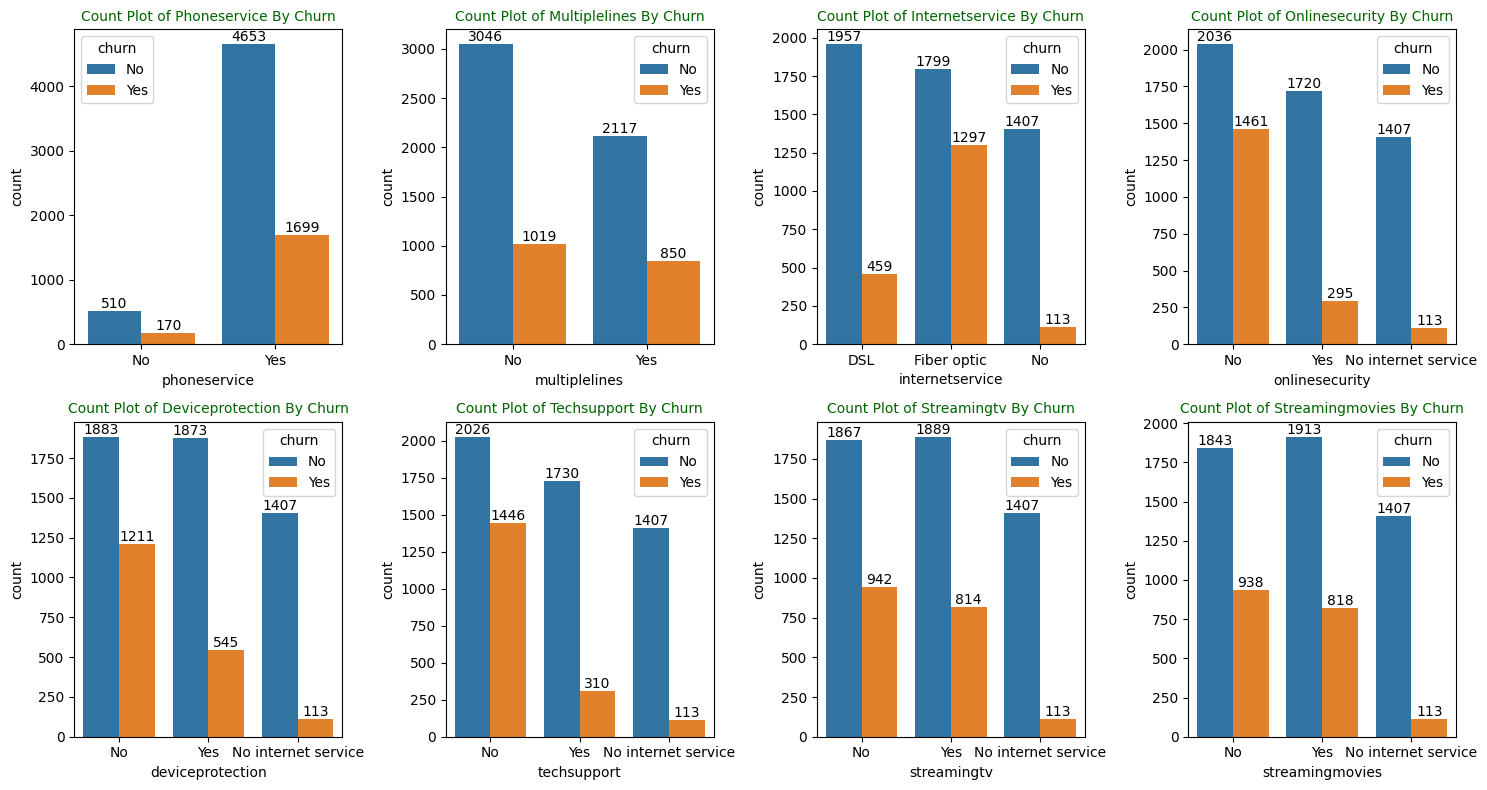

In [22]:
cols = ['phoneservice','multiplelines','internetservice','onlinesecurity','deviceprotection','techsupport','streamingtv','streamingmovies']

plt.figure(figsize=(15, 8))

for i in range(len(cols)):
    plt.subplot(2, 4, i+1)
    ax = sns.countplot(x=f"{cols[i]}", data=df,hue='churn')
    ax.bar_label(ax.containers[0])
    ax.bar_label(ax.containers[1])
    plt.title(f"Count Plot of {cols[i].capitalize()} By Churn", color='darkgreen', fontsize=10)

plt.tight_layout()
plt.show()

#Customers using Fiber Optic internet have the highest churn, while customers with Online Security, Device Protection, and Tech Support are more likely to stay with the company. Phone Service, Multiple Lines, Streaming TV, and Streaming Movies have little impact on customer churn. This suggests that improving service quality and value-added support can help reduce customer churn.